Actividad 2: Modelado predictivo y Clasificación de riesdo con casos de dengue en México.

Lo primero que haremos será importar nuestra base de datos de los casos semanales del dengue por entidad federativa, en un periodo entre 2020 y 2025.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Parte 1. Carga y Exploración de datos**

In [93]:
ruta = "https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Datos/casos_dengue_2020-2025.csv"
df = pd.read_csv(ruta)
df

,FECHA,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,COAHUILA,COLIMA,DISTRITO FEDERAL,...,QUINTANA ROO,SAN LUIS POTOSI,SINALOA,SONORA,TABASCO,TAMAULIPAS,TLAXCALA,VERACRUZ,YUCATAN,ZACATECAS
0,2020-01-05,0,2,4,36,41,1,4,23,6,...,106,47,40,8,112,111,0,249,58,3
1,2020-01-12,0,2,3,37,83,5,1,37,6,...,167,74,46,13,158,206,0,441,62,0
2,2020-01-19,0,0,3,31,73,0,4,40,2,...,158,80,48,12,166,190,0,412,73,2
3,2020-01-26,1,1,2,45,57,0,1,39,3,...,130,53,54,13,167,191,1,418,54,1
4,2020-02-02,0,0,2,40,54,0,1,32,0,...,99,43,48,9,139,173,1,322,45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277,2025-04-27,3,3,11,24,72,0,13,30,9,...,79,36,36,7,84,100,0,245,50,0
278,2025-05-04,9,2,8,27,93,0,3,37,4,...,92,36,37,9,82,76,0,206,42,0
279,2025-05-11,2,1,17,24,102,0,7,45,4,...,114,46,25,13,91,125,0,296,54,1
280,2025-05-18,10,3,15,14,105,1,9,42,5,...,93,37,31,13,110,103,1,331,58,0


Veamos cuántas filas y cuántas columnas hay en nuestra tabla de datos.

In [94]:
print(df.shape)
print(df.columns)

(282, 33)
Index(['FECHA', 'AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR',
       'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'COAHUILA', 'COLIMA',
       'DISTRITO FEDERAL', 'DURANGO', 'GUANAJUATO', 'GUERRERO', 'HIDALGO',
       'JALISCO', 'MEXICO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'NUEVO LEON',
       'OAXACA', 'PUEBLA', 'QUERETARO', 'QUINTANA ROO', 'SAN LUIS POTOSI',
       'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'TLAXCALA', 'VERACRUZ',
       'YUCATAN', 'ZACATECAS'],
      dtype='object')


Tenemos: 282 filas y 33 columnas.

Cuál es el periodo temporal cubierto por nuestros datos?

In [95]:
df['FECHA'] = pd.to_datetime(df['FECHA'])
fecha_inicio = df['FECHA'].min()
fecha_fin = df['FECHA'].max()

print("Periodo temporal cubierto:")
print("Inicio:", fecha_inicio.date())
print("Fin:", fecha_fin.date())



Periodo temporal cubierto:
Inicio: 2020-01-05
Fin: 2025-05-25


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   FECHA                282 non-null    datetime64[ns]
 1   AGUASCALIENTES       282 non-null    int64         
 2   BAJA CALIFORNIA      282 non-null    int64         
 3   BAJA CALIFORNIA SUR  282 non-null    int64         
 4   CAMPECHE             282 non-null    int64         
 5   CHIAPAS              282 non-null    int64         
 6   CHIHUAHUA            282 non-null    int64         
 7   COAHUILA             282 non-null    int64         
 8   COLIMA               282 non-null    int64         
 9   DISTRITO FEDERAL     282 non-null    int64         
 10  DURANGO              282 non-null    int64         
 11  GUANAJUATO           282 non-null    int64         
 12  GUERRERO             282 non-null    int64         
 13  HIDALGO              282 non-null  

Tenemos 32 entidades federativas, las cuales aparecen en la celda anterior.

Lo que haremos ahora es identificar la variable temporal y los estados o entidades federativas.

In [97]:
df["FECHA"] = pd.to_datetime(df["FECHA"])

cols_estados = [col for col in df.columns if col != "FECHA"]

print("Número de estados:", len(cols_estados))
print(cols_estados)

Número de estados: 32
['AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR', 'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'COAHUILA', 'COLIMA', 'DISTRITO FEDERAL', 'DURANGO', 'GUANAJUATO', 'GUERRERO', 'HIDALGO', 'JALISCO', 'MEXICO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'NUEVO LEON', 'OAXACA', 'PUEBLA', 'QUERETARO', 'QUINTANA ROO', 'SAN LUIS POTOSI', 'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'TLAXCALA', 'VERACRUZ', 'YUCATAN', 'ZACATECAS']


Veamos si hay valores faltantes.

In [98]:
df.isna().sum()

,0
FECHA,0
AGUASCALIENTES,0
BAJA CALIFORNIA,0
BAJA CALIFORNIA SUR,0
CAMPECHE,0
CHIAPAS,0
CHIHUAHUA,0
COAHUILA,0
COLIMA,0
DISTRITO FEDERAL,0


In [99]:
faltantes = df.isna().sum()
print(faltantes[faltantes > 0])

Series([], dtype: int64)


In [100]:
print("Total de valores faltantes:", df.isna().sum().sum())

Total de valores faltantes: 0


No hay valores faltantes, esto significa que no hubo errores de captura o bien que no falta información.

Ahora construyamos una serie nacional sumando los casos de todas las entidades federativas para cada semana. La denotaremos
$$C_{t}=casos \ nacionales \ de \ dengue\ en \ la \ semana \ t$$

In [101]:
df["casos_semana"] = df[cols_estados].sum(axis=1)

casos_totales = df[["FECHA", "casos_semana"]]

In [102]:
casos_totales

,FECHA,casos_semana
0,2020-01-05,1318
1,2020-01-12,2068
2,2020-01-19,2078
3,2020-01-26,1973
4,2020-02-02,1562
...,...,...
277,2025-04-27,1504
278,2025-05-04,1549
279,2025-05-11,1878
280,2025-05-18,1932


Incluso, podríamos generar un análisis general de nuestra serie construida.

In [103]:
print("Número de semanas:", len(df))
print("Total acumulado de casos:", df["casos_semana"].sum())
print("Promedio semanal:", df["casos_semana"].mean())
print("Mediana semanal:", df["casos_semana"].median())
print("Máximo semanal:", df["casos_semana"].max())

Número de semanas: 282
Total acumulado de casos: 1077917
Promedio semanal: 3822.400709219858
Mediana semanal: 1631.5
Máximo semanal: 27869


Ya vimos que el máximo semanal es de 27869 casos de dengue, pero veamos en qué semana fué ese máximo.

In [104]:
idx_pico = df["casos_semana"].idxmax()

print("Semana pico:")
print(df.loc[idx_pico, ["FECHA", "casos_semana"]])

Semana pico:
FECHA           2024-09-22 00:00:00
casos_semana                  27869
Name: 246, dtype: object


Veamos la información de nuestra serie de casos nacionales de dengue, en una gráfica.

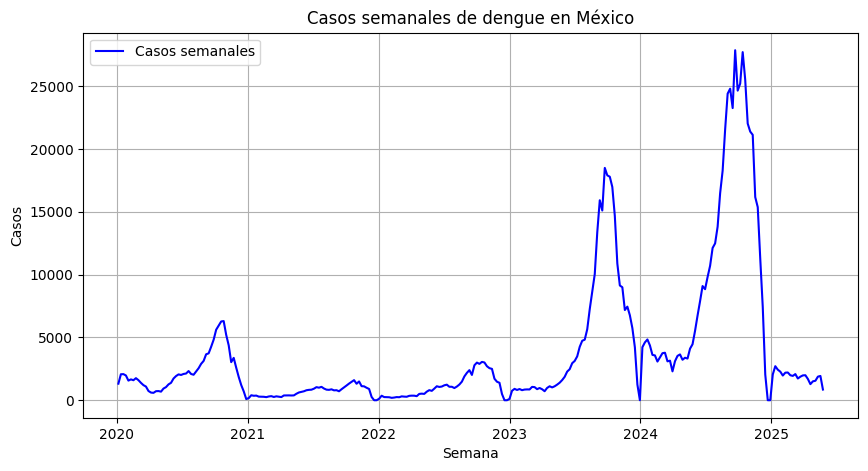

In [105]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["FECHA"],
    df["casos_semana"],
    label="Casos semanales",
    color="blue"
)

plt.xlabel("Semana")
plt.ylabel("Casos")
plt.title("Casos semanales de dengue en México")
plt.legend()
plt.grid()

plt.show()

 Podemos observar al menos 3 picos de información, el primero de ellos mas o menos en septiempbre u octubre del 2020, el segundo de ellos en agosto del 2023 y el último de ellos en la semana pico, septiembre del 2024.

 Los aumentos de contagios parecen concentrarse en el último tercio de cada año, es decir, en el periodo de septiembre-diciembre.

 Claramente, la serie tiene un comportamiento variable pues hay muchos factores que determinan el número de contagios de dengue, por ejemplo si estuviste directamente expuesto con algun contagiado, o si ya fuiste vacunado, etc.

 De hecho, no podemos observar un posible patrón estacional, pues como se mencionó antes, el número de contagios siempre va a ser variable.

 Un modelo de predicción para esta serie podría tener problemas, uno de ellos puede ser un sobre ajuste en los datos, lo que nos daría predicciones erroneas, que como hay decensos en el número de contagios, podría predecir números negativos de contagios.

Parte 2. Construcción de variables temporales.

Construyamos los rezagos temporales, $C_{t-1},\ C_{t-2}, \ C_{t-3}, \ C_{t-4}$

In [106]:
df["lag_1"] = df["casos_semana"].shift(1)
df["lag_2"] = df["casos_semana"].shift(2)
df["lag_3"] = df["casos_semana"].shift(3)
df["lag_4"] = df["casos_semana"].shift(4)

df[["FECHA", "casos_semana", "lag_1", "lag_2", "lag_3", "lag_4"]]

,FECHA,casos_semana,lag_1,lag_2,lag_3,lag_4
0,2020-01-05,1318,NaN,NaN,NaN,NaN
1,2020-01-12,2068,1318.0,NaN,NaN,NaN
2,2020-01-19,2078,2068.0,1318.0,NaN,NaN
3,2020-01-26,1973,2078.0,2068.0,1318.0,NaN
4,2020-02-02,1562,1973.0,2078.0,2068.0,1318.0
...,...,...,...,...,...,...
277,2025-04-27,1504,1280.0,1693.0,1990.0,1977.0
278,2025-05-04,1549,1504.0,1280.0,1693.0,1990.0
279,2025-05-11,1878,1549.0,1504.0,1280.0,1693.0
280,2025-05-18,1932,1878.0,1549.0,1504.0,1280.0


Ahora vamos a construir el promedio móvil, considerado a 3 y 5 semanas, es decir $MA_{3}$ y $MA_{5}$, donde

$$MA_{3}=\frac{C_{3}+C_{2}+C_{1}}{3}$$

$$MA_{5}=\frac{C_{5}+C_{4}+C_{3}+C_{2}+C_{1}}{5}$$

In [107]:
df["promedio_movil_3"] = df["casos_semana"].rolling(window=3).mean()
df["promedio_movil_5"] = df["casos_semana"].rolling(window=5).mean()

df[["FECHA", "casos_semana", "promedio_movil_3", "promedio_movil_5"]]


,FECHA,casos_semana,promedio_movil_3,promedio_movil_5
0,2020-01-05,1318,NaN,NaN
1,2020-01-12,2068,NaN,NaN
2,2020-01-19,2078,1821.333333,NaN
3,2020-01-26,1973,2039.666667,NaN
4,2020-02-02,1562,1871.000000,1799.8
...,...,...,...,...
277,2025-04-27,1504,1492.333333,1688.8
278,2025-05-04,1549,1444.333333,1603.2
279,2025-05-11,1878,1643.666667,1580.8
280,2025-05-18,1932,1786.333333,1628.6


Podemos visualizar el comportamiento del promedio móvil en una gráfica.

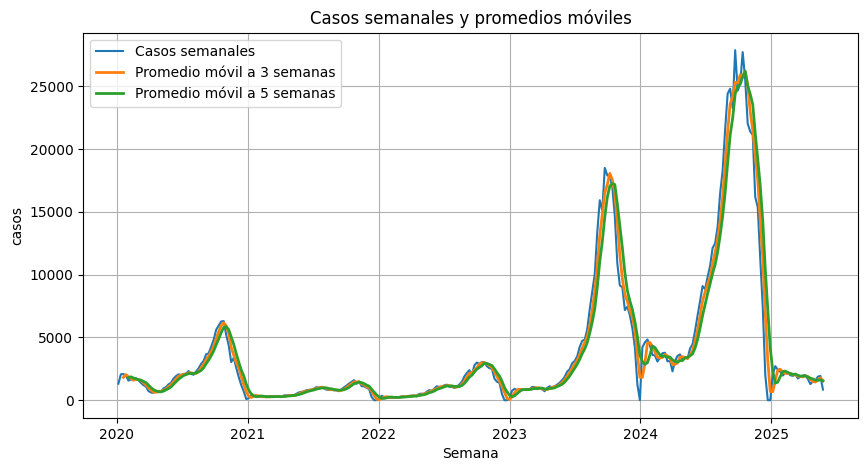

In [108]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["FECHA"],
    df["casos_semana"],
    label="Casos semanales"
)

plt.plot(
    df["FECHA"],
    df["promedio_movil_3"],
    linewidth=2,
    label="Promedio móvil a 3 semanas"
)

plt.plot(
    df["FECHA"],
    df["promedio_movil_5"],
    linewidth=2,
    label="Promedio móvil a 5 semanas"
)

plt.xlabel("Semana")
plt.ylabel("casos")
plt.title("Casos semanales y promedios móviles")
plt.legend()
plt.grid()

plt.show()



Como se puede observar del gráfico, los promedios móviles presentan una gráfica con curvas más suaves, que nos permiten hacer un mejor análisis en los picos de información.

La siguiente tabla de datos condensa toda la información de casos semanales, rezagos temporales y promedios móviles.

In [109]:
df[["FECHA", "casos_semana","lag_1", "lag_2", "lag_3", "lag_4", "promedio_movil_3", "promedio_movil_5"]].head(10)

,FECHA,casos_semana,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5
0,2020-01-05,1318,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-12,2068,1318.0,NaN,NaN,NaN,NaN,NaN
2,2020-01-19,2078,2068.0,1318.0,NaN,NaN,1821.333333,NaN
3,2020-01-26,1973,2078.0,2068.0,1318.0,NaN,2039.666667,NaN
4,2020-02-02,1562,1973.0,2078.0,2068.0,1318.0,1871.000000,1799.8
5,2020-02-09,1659,1562.0,1973.0,2078.0,2068.0,1731.333333,1868.0
6,2020-02-16,1593,1659.0,1562.0,1973.0,2078.0,1604.666667,1773.0
7,2020-02-23,1756,1593.0,1659.0,1562.0,1973.0,1669.333333,1708.6
8,2020-03-01,1598,1756.0,1593.0,1659.0,1562.0,1649.000000,1633.6
9,2020-03-08,1384,1598.0,1756.0,1593.0,1659.0,1579.333333,1598.0


Calculemos el cambio semanal
$$\Delta C_{t}=C_{t}-C_{t-1}$$

In [110]:
df["cambio_semanal"] = df["casos_semana"].diff()
df[["FECHA", "casos_semana", "cambio_semanal", "lag_1", "lag_2", "lag_3", "lag_4", "promedio_movil_3", "promedio_movil_5" ]]

,FECHA,casos_semana,cambio_semanal,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5
0,2020-01-05,1318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-12,2068,750.0,1318.0,NaN,NaN,NaN,NaN,NaN
2,2020-01-19,2078,10.0,2068.0,1318.0,NaN,NaN,1821.333333,NaN
3,2020-01-26,1973,-105.0,2078.0,2068.0,1318.0,NaN,2039.666667,NaN
4,2020-02-02,1562,-411.0,1973.0,2078.0,2068.0,1318.0,1871.000000,1799.8
...,...,...,...,...,...,...,...,...,...
277,2025-04-27,1504,224.0,1280.0,1693.0,1990.0,1977.0,1492.333333,1688.8
278,2025-05-04,1549,45.0,1504.0,1280.0,1693.0,1990.0,1444.333333,1603.2
279,2025-05-11,1878,329.0,1549.0,1504.0,1280.0,1693.0,1643.666667,1580.8
280,2025-05-18,1932,54.0,1878.0,1549.0,1504.0,1280.0,1786.333333,1628.6


El siguiente gráfico muestra el comportamiento de la variable "cambio semanal", pues en ella podemos interpretar si aumentan los casos o diminuyen.

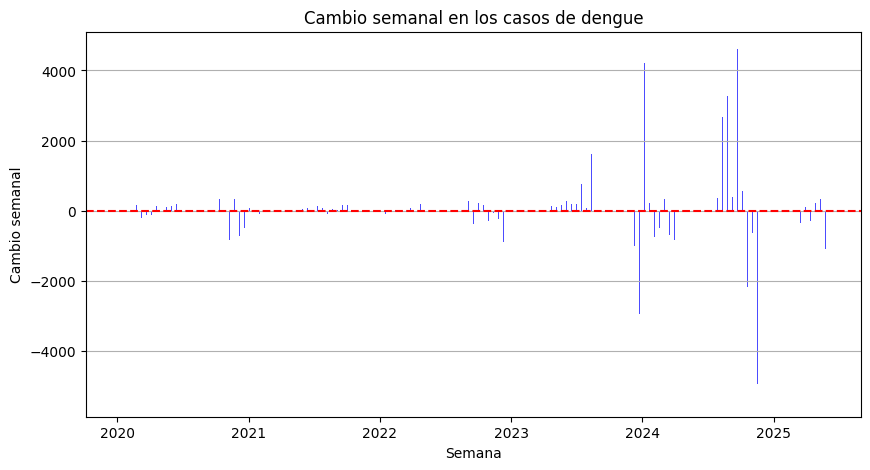

In [111]:
plt.figure(figsize=(10, 5))

plt.axhline(y=0, linestyle="--", color='red')
plt.bar(df["FECHA"], df["cambio_semanal"], color='blue', alpha=0.7)

plt.xlabel("Semana")
plt.ylabel("Cambio semanal")
plt.title("Cambio semanal en los casos de dengue")
plt.grid(axis="y")

plt.show()

Observemos que a finales de los años 2024 y 2025, se presentaron los mayores registros de contagios semanales de dengue.

Naturalmente, necesitamos una variable objetivo para predicción. Construyamos esta variable y la llamaremos "casos_siguiente_semana"

In [112]:
df["casos_siguiente_semana"] = df["casos_semana"].shift(-1)

df_modelo = df[[
    "FECHA",
    "casos_semana",
    "cambio_semanal",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "casos_siguiente_semana"
]].copy()

df_modelo.head(10)

,FECHA,casos_semana,cambio_semanal,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,casos_siguiente_semana
0,2020-01-05,1318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2068.0
1,2020-01-12,2068,750.0,1318.0,NaN,NaN,NaN,NaN,NaN,2078.0
2,2020-01-19,2078,10.0,2068.0,1318.0,NaN,NaN,1821.333333,NaN,1973.0
3,2020-01-26,1973,-105.0,2078.0,2068.0,1318.0,NaN,2039.666667,NaN,1562.0
4,2020-02-02,1562,-411.0,1973.0,2078.0,2068.0,1318.0,1871.000000,1799.8,1659.0
5,2020-02-09,1659,97.0,1562.0,1973.0,2078.0,2068.0,1731.333333,1868.0,1593.0
6,2020-02-16,1593,-66.0,1659.0,1562.0,1973.0,2078.0,1604.666667,1773.0,1756.0
7,2020-02-23,1756,163.0,1593.0,1659.0,1562.0,1973.0,1669.333333,1708.6,1598.0
8,2020-03-01,1598,-158.0,1756.0,1593.0,1659.0,1562.0,1649.000000,1633.6,1384.0
9,2020-03-08,1384,-214.0,1598.0,1756.0,1593.0,1659.0,1579.333333,1598.0,1200.0


Eliminemos filas incompletas.

In [113]:
df_modelo = df_modelo.dropna()
df_modelo.head()

,FECHA,casos_semana,cambio_semanal,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,casos_siguiente_semana
4,2020-02-02,1562,-411.0,1973.0,2078.0,2068.0,1318.0,1871.000000,1799.8,1659.0
5,2020-02-09,1659,97.0,1562.0,1973.0,2078.0,2068.0,1731.333333,1868.0,1593.0
6,2020-02-16,1593,-66.0,1659.0,1562.0,1973.0,2078.0,1604.666667,1773.0,1756.0
7,2020-02-23,1756,163.0,1593.0,1659.0,1562.0,1973.0,1669.333333,1708.6,1598.0
8,2020-03-01,1598,-158.0,1756.0,1593.0,1659.0,1562.0,1649.000000,1633.6,1384.0


Esta tabla ya tiene la estructura de un modelo predictivo sencillo, donde nuestras variables predictoras son
$$X = C_{t}C_{t-1}C_{t-2}C_{t-3}C_{t-4}MA_{3}MA_{5}$$

y nuestra variable objetivo sería
$$y=C_{t+1}$$

In [114]:
X = df_modelo[["casos_semana", "lag_1", "lag_2", "lag_3", "lag_4", "promedio_movil_3", "promedio_movil_5"]]

y = df_modelo["casos_siguiente_semana"]

print(X.head())
print(y.head())

   casos_semana   lag_1   lag_2   lag_3   lag_4  promedio_movil_3  \
4          1562  1973.0  2078.0  2068.0  1318.0       1871.000000   
5          1659  1562.0  1973.0  2078.0  2068.0       1731.333333   
6          1593  1659.0  1562.0  1973.0  2078.0       1604.666667   
7          1756  1593.0  1659.0  1562.0  1973.0       1669.333333   
8          1598  1756.0  1593.0  1659.0  1562.0       1649.000000   

   promedio_movil_5  
4            1799.8  
5            1868.0  
6            1773.0  
7            1708.6  
8            1633.6  
4    1659.0
5    1593.0
6    1756.0
7    1598.0
8    1384.0
Name: casos_siguiente_semana, dtype: float64


Para complementar este análisis preliminar, analicemos que estados presentan más casos acumulados.

In [115]:
casos_estado = df[cols_estados].sum().sort_values(ascending=False)

print(casos_estado)

JALISCO                131329
VERACRUZ                91491
GUERRERO                83467
MORELOS                 77530
OAXACA                  66625
YUCATAN                 60319
MICHOACAN               49573
NUEVO LEON              47576
NAYARIT                 45895
QUINTANA ROO            43628
CHIAPAS                 41855
TABASCO                 40661
COLIMA                  37026
TAMAULIPAS              35119
PUEBLA                  33752
SINALOA                 31447
COAHUILA                27111
SAN LUIS POTOSI         23309
GUANAJUATO              20924
CAMPECHE                17758
MEXICO                  14011
SONORA                  13482
BAJA CALIFORNIA SUR     11351
QUERETARO               10064
AGUASCALIENTES           7396
HIDALGO                  7283
DURANGO                  4146
DISTRITO FEDERAL         1459
BAJA CALIFORNIA           940
CHIHUAHUA                 773
ZACATECAS                 483
TLAXCALA                  134
dtype: int64


Veamos cual es el top 10 de los estados con el mayor número de contagios

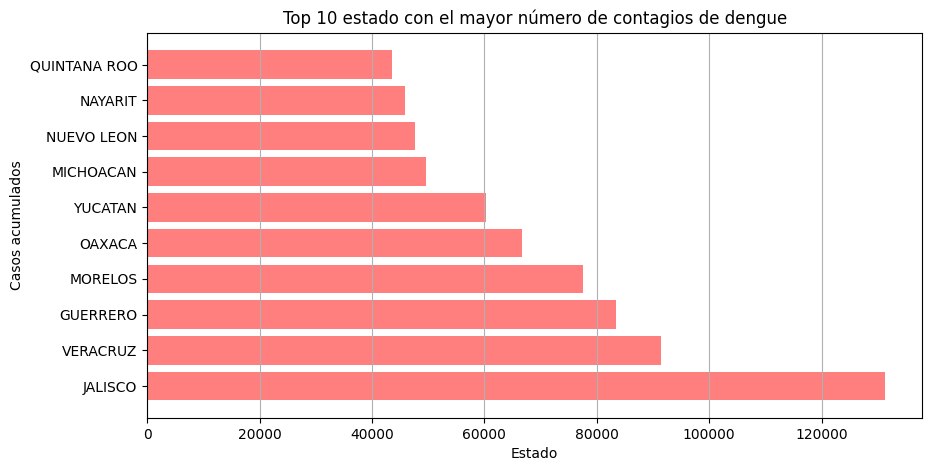

In [116]:
top10 = casos_estado.head(10)
plt.figure(figsize=(10, 5))

plt.barh(top10.index, top10.values, color='red', alpha=0.5)

plt.xlabel("Estado")
plt.ylabel("Casos acumulados")
plt.title("Top 10 estado con el mayor número de contagios de dengue")
plt.grid(axis="x")
plt.show()

Observemos que los contagios se concentran en su mayoria en Yucatán, Oaxaca, Morelos, Guerrero, Veracruz y principalmente en Jalisco, donde se observa una diferencia considerable entre los contagios en Jalisco y los contagios en los demás estados, pues en comparación con el segundo estado con más contagios, hay una diferencia aproximada de casi 4 mil contagios.

Para hacer un mejor análisis necesitamos información adicional, por ejemplo, saber si en el estado, su población ya fué vacunada o no, al igual saber cual es la tasa de incidencia pues el echo de que jalisco presente la mayor cantidad de casos de dengue, no significa que sea el de mayor contagio.

**Parte 3: Predicción de casos semanales.**

Consideremos el problema como un problema de regresión lineal, este será nuestro primer modelo predictivo.

Preparemos nuestra tabla final para modelado.

In [117]:
columnas_modelo = [
    "FECHA",
    "casos_semana",
    "cambio_semanal",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "casos_siguiente_semana"
]

df_modelo = df[columnas_modelo].dropna().reset_index(drop=True)

df_modelo.head()

,FECHA,casos_semana,cambio_semanal,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,casos_siguiente_semana
0,2020-02-02,1562,-411.0,1973.0,2078.0,2068.0,1318.0,1871.000000,1799.8,1659.0
1,2020-02-09,1659,97.0,1562.0,1973.0,2078.0,2068.0,1731.333333,1868.0,1593.0
2,2020-02-16,1593,-66.0,1659.0,1562.0,1973.0,2078.0,1604.666667,1773.0,1756.0
3,2020-02-23,1756,163.0,1593.0,1659.0,1562.0,1973.0,1669.333333,1708.6,1598.0
4,2020-03-01,1598,-158.0,1756.0,1593.0,1659.0,1562.0,1649.000000,1633.6,1384.0


Sea $X$ la información disponible hasta la semana $t$ y $y$ los casos observados en la semana $t+1$

In [118]:
variables_predictoras = [
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal"
    ]

X = df_modelo[variables_predictoras]
y = df_modelo["casos_siguiente_semana"]

print(X.head())
print(y.head())

   casos_semana   lag_1   lag_2   lag_3   lag_4  promedio_movil_3  \
0          1562  1973.0  2078.0  2068.0  1318.0       1871.000000   
1          1659  1562.0  1973.0  2078.0  2068.0       1731.333333   
2          1593  1659.0  1562.0  1973.0  2078.0       1604.666667   
3          1756  1593.0  1659.0  1562.0  1973.0       1669.333333   
4          1598  1756.0  1593.0  1659.0  1562.0       1649.000000   

   promedio_movil_5  cambio_semanal  
0            1799.8          -411.0  
1            1868.0            97.0  
2            1773.0           -66.0  
3            1708.6           163.0  
4            1633.6          -158.0  
0    1659.0
1    1593.0
2    1756.0
3    1598.0
4    1384.0
Name: casos_siguiente_semana, dtype: float64


Hagamos nuestra división de los datos en Datos de entrenamiento y Datos de prueba.

In [119]:
n = len(df_modelo)

n_train = int(0.7 * n)
df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["casos_siguiente_semana"]

X_test = df_test[variables_predictoras]
y_test = df_test["casos_siguiente_semana"]

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (193, 8)
Tamaño del conjunto de prueba: (84, 8)


Visualicemos ambos conjuntos en el siguiente gráfico.

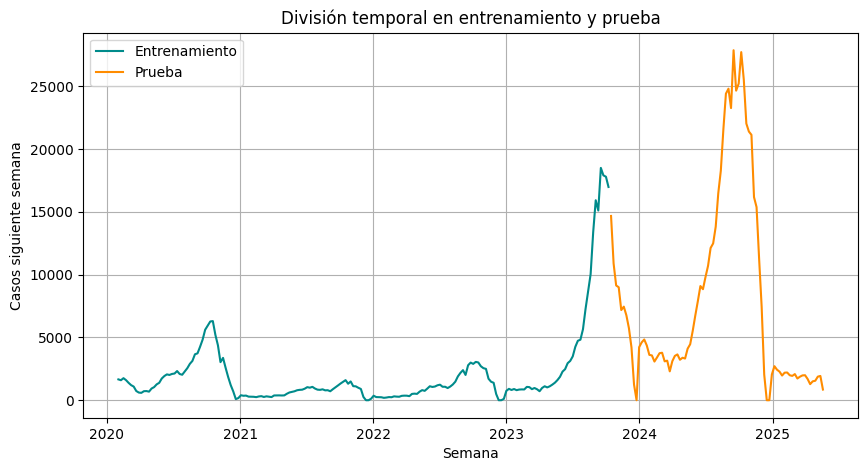

In [120]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_train["FECHA"],
    df_train["casos_siguiente_semana"],
    label="Entrenamiento",
    color='darkcyan'
)

plt.plot(
    df_test["FECHA"],
    df_test["casos_siguiente_semana"],
    label="Prueba",
    color='darkorange'
)

plt.xlabel("Semana")
plt.ylabel("Casos siguiente semana")
plt.title("División temporal en entrenamiento y prueba")
plt.xticks()
plt.legend()
plt.grid()
plt.show()

Modelo base: Predicción ingenua: $\widehat{C}_{t+1}=C_{t}$, es decir, vamos a suponer que los casos registrados la siguiente semana serán iguales a los de la semana en curso.

In [121]:
df_test["pred_naive"] = df_test["casos_semana"]

df_test[[
    "FECHA",
    "casos_semana",
    "casos_siguiente_semana",
    "pred_naive"
]]

,FECHA,casos_semana,casos_siguiente_semana,pred_naive
193,2023-10-15,16980,14673.0,16980
194,2023-10-22,14673,10886.0,14673
195,2023-10-29,10886,9136.0,10886
196,2023-11-05,9136,8996.0,9136
197,2023-11-12,8996,7181.0,8996
...,...,...,...,...
272,2025-04-20,1280,1504.0,1280
273,2025-04-27,1504,1549.0,1504
274,2025-05-04,1549,1878.0,1549
275,2025-05-11,1878,1932.0,1878


Ahora definamos nuestras métricas error $MAE$ y $RMSE$, para ver que tan precisa fué nuestra primera predicción.

In [122]:
def calcular_metricas(y_real, y_pred):
  error = y_real - y_pred

  mae = np.mean(np.abs(error))
  rmse = np.sqrt(np.mean(error**2))

  return mae, rmse

In [123]:
mae_naive, rmse_naive = calcular_metricas(
    df_test["casos_siguiente_semana"],
    df_test["pred_naive"]
)

In [124]:
print("Modelo ingenuo")
print("MAE:", mae_naive)
print("RMSE:", rmse_naive)

Modelo ingenuo
MAE: 1163.3690476190477
RMSE: 1751.9682434880137


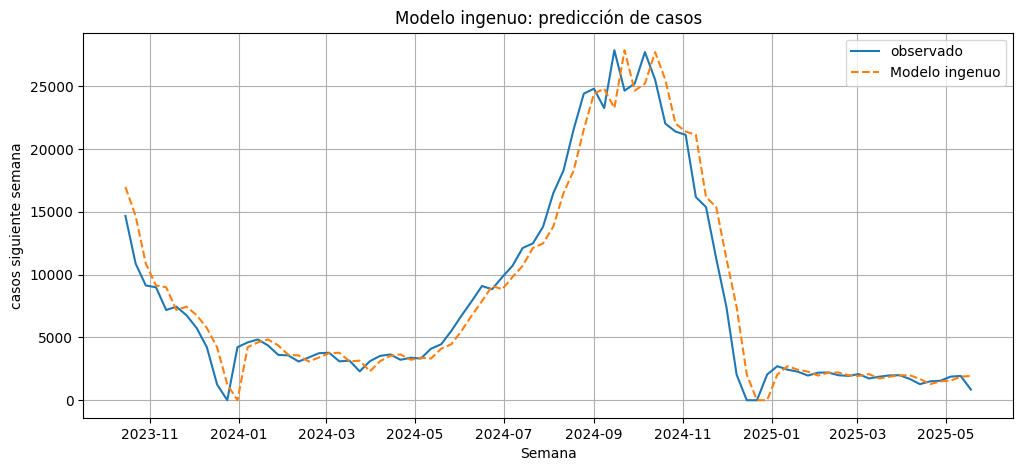

In [125]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_test["FECHA"],
    df_test["casos_siguiente_semana"],
    label="observado"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_naive"],
    linestyle="--",
    label="Modelo ingenuo"
)


plt.xlabel("Semana")
plt.ylabel("casos siguiente semana")
plt.title("Modelo ingenuo: predicción de casos")
plt.legend()
plt.grid()

plt.show()

A primera vista paraece una buena predicción, claro que podríamos mejorar nuestras predicciones, veamos algunas de ellas y comencemos a comparar.

Nuestro segundo modelo a comparar será una regresión lineal.

In [126]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression() #inicializamos un modelo en blanco.

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

In [127]:
mae_lr, rmse_lr = calcular_metricas(y_test, pred_lr)

print("Regresión Lineal")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Regresión Lineal
MAE: 1166.2225149227531
RMSE: 1682.1244938533528


Comparemos el valor del $MAE$ considerando el modelo ingenuo y la regresión lineal:

MAE (Ingenuo) = 1163.369

MAE (Regresión Lineal) = 1166.222

Mientras que para el $RMSE$:

RMSE (Ingenuo) = 1751.968

RMSE (Regresión Lineal) = 1682.124

Podemos observar que la regresión lineal tiene un menor $RMSE$ sin embargo no es mucha la direfencia, significa que ambos modelos tienen una predicción muy similar, donde podríamos decir que la regresión lineal es un poco más precisa. Con respecto al $MAE$ de ambos modelos, este valor es prácticamente el mismo, por lo que reafirmamos que la regresión lineal es más precisa.

Como estamos estudiando predicciones de contagios de dengue, no tiene sentido obtener valores negativos, por lo tanto asegurémonos de no considerarlos.

In [128]:
pred_lr_no_neg = np.maximum(pred_lr, 0)
mae_lr_no_neg, rmse_lr_no_neg = calcular_metricas(
    y_test,
    pred_lr_no_neg
)

print("Regresión lineal truncada a cero")
print("MAE:", mae_lr_no_neg)
print("RMSE:", rmse_lr_no_neg)

Regresión lineal truncada a cero
MAE: 1025.162123363624
RMSE: 1430.1695059892536


Observemos que la regresión lineal no negativa tiene mejores valores de $MAE$ y del $RMSE$ en comparación con los otros dos modelos. Comparemos Los tres modelos en la siguiente tabla.

In [129]:
df_metricas = pd.DataFrame({
    "modelo": [
        "Naive",
        "Regresión lineal",
        "Regresión lineal no negativa"
    ],
    "MAE": [
        mae_naive,
        mae_lr,
        mae_lr_no_neg
    ],
    "RMSE": [
        rmse_naive,
        rmse_lr,
        rmse_lr_no_neg
    ]
})

df_metricas

,modelo,MAE,RMSE
0,Naive,1163.369048,1751.968243
1,Regresión lineal,1166.222515,1682.124494
2,Regresión lineal no negativa,1025.162123,1430.169506


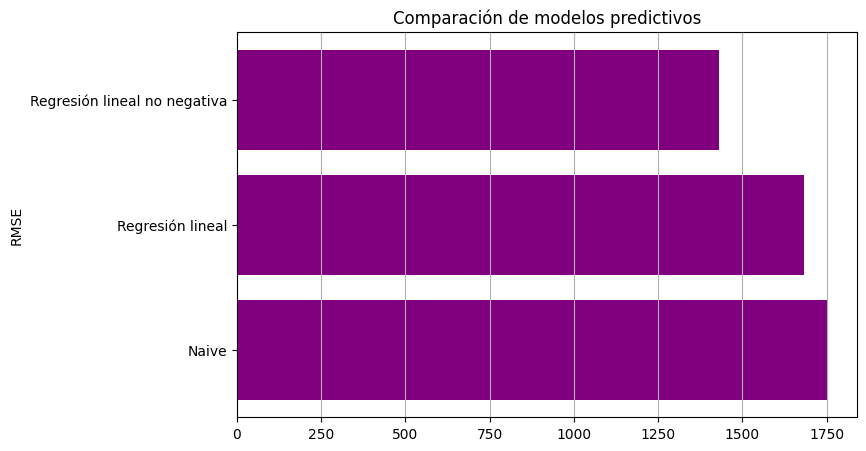

In [130]:
plt.figure(figsize=(8, 5))

plt.barh(df_metricas["modelo"], df_metricas["RMSE"], color='purple')
plt.ylabel("RMSE")
plt.title("Comparación de modelos predictivos")
plt.grid(axis="x")

plt.show()


Con esto podemos apreciar lo que se comentaba con anterioridad, el modelo de menor RMSE entre los tres comparados es la regresión lineal no negativa, por lo que hasta el momendo es nuestro modelo más preciso.

In [131]:
df_test["pred_lr"] = pred_lr
df_test["pred_lr_no_neg"] = pred_lr_no_neg

df_test[["FECHA", "casos_siguiente_semana", "pred_naive", "pred_lr_no_neg"]]

,FECHA,casos_siguiente_semana,pred_naive,pred_lr_no_neg
193,2023-10-15,14673.0,16980,15781.281055
194,2023-10-22,10886.0,14673,13113.674815
195,2023-10-29,9136.0,10886,8363.258303
196,2023-11-05,8996.0,9136,5817.734133
197,2023-11-12,7181.0,8996,6246.247842
...,...,...,...,...
272,2025-04-20,1504.0,1280,1119.992249
273,2025-04-27,1549.0,1504,1268.426657
274,2025-05-04,1878.0,1549,1505.922682
275,2025-05-11,1932.0,1878,2033.516294


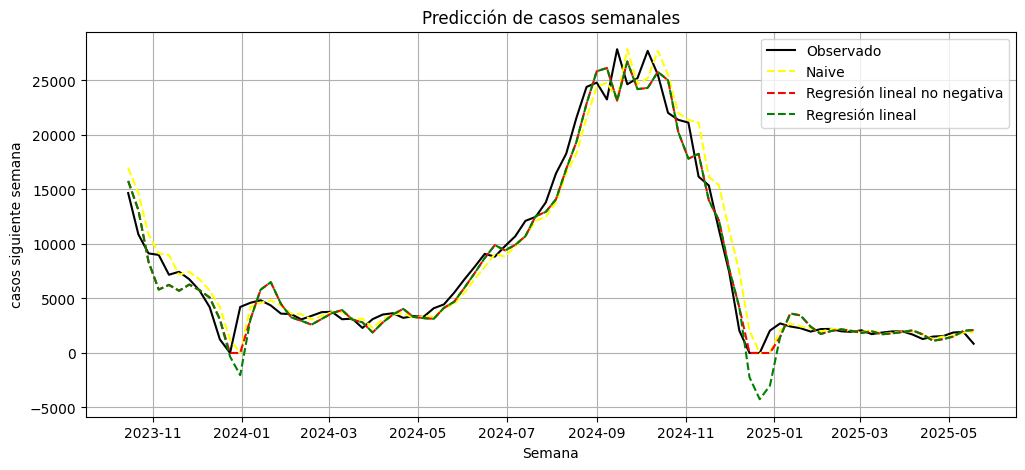

In [132]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_test["FECHA"],
    df_test["casos_siguiente_semana"],
    #marker="o",
    color='black',
    label="Observado"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_naive"],
    #marker="s",
    linestyle="--",
    label="Naive",
    color='yellow'
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_lr_no_neg"],
    #marker="^",
    linestyle="--",
    color='red',
    label="Regresión lineal no negativa"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_lr"],
    #marker="^",
    linestyle="--",
    color='green',
    label="Regresión lineal"
)


plt.xlabel("Semana")
plt.ylabel("casos siguiente semana")
plt.title("Predicción de casos semanales")
plt.legend()
plt.grid()

plt.show()

Observemos que aunque los tres modelos comparados predicen bastante bien los casos observados, el mejor de ellos es la regresión lineal no negativa, donde se puede apreciar que sus datos se asemejan más a los observados, lo que conincide con ser la de menor $RMSE$.

Veamos cuales fueron las variables predictoras más importantes para la regresión lineal.

In [133]:
df_coef = pd.DataFrame({
    "variable": variables_predictoras,
    "coeficiente": modelo_lr.coef_
})

df_coef = df_coef.sort_values("coeficiente", ascending=False)

df_coef

,variable,coeficiente
0,casos_semana,0.707116
1,lag_1,0.422254
5,promedio_movil_3,0.317921
7,cambio_semanal,0.284862
6,promedio_movil_5,0.104098
4,lag_4,-0.048244
2,lag_2,-0.175607
3,lag_3,-0.385029


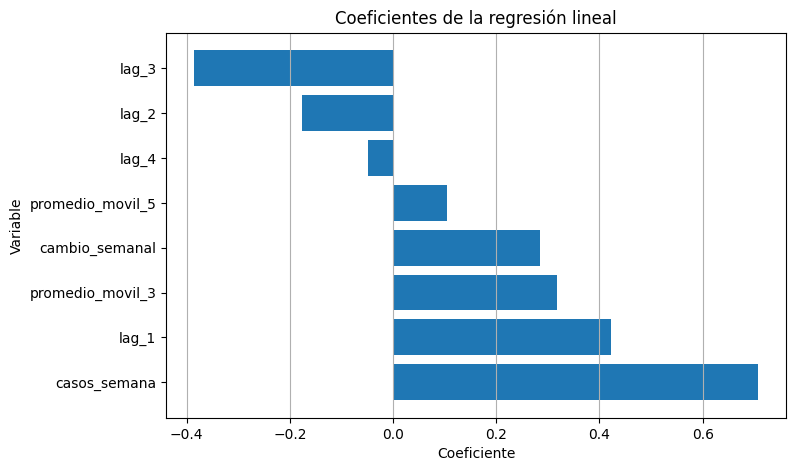

In [134]:
plt.figure(figsize=(8, 5))

plt.barh(df_coef["variable"], df_coef["coeficiente"])

plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.title("Coeficientes de la regresión lineal")
plt.grid(axis="x")

plt.show()

Hagamos un análisis de la información obtenida.

casos_semana(0.7071): Esta es la variable predictora más fuerte. Dice que por cada caso adicional confirmado de dengue, el modelo proyecta 0.7071 aproximadamente de casos extra para la siguiente semana.

lag_1(0.422): La cantidad de casos confirmados de la semana pasada también es muy importante para el modelo, por cada caso de la semana anterior se añaden aproximadamente 0.422 casos para la predicción futura.

promedio_movil_3(0.317): Esta variable es importante pero en menor medida que las dos anteriores, indica que en promedio se predicen aproximandamente 0.317 casos en base al promedio de contagios de las últimas 3 semanas.

cambio_semanal(0.284): Esta es otra variable que tuvo peso en el modelo pero fué de menor importancia que las anteriores, al igual que sucedió con el promedio_movil_5. El cambio semanal significa que si la curva viene en un ascenso pronunciado, es decir, con un crecimiento acelerado, el modelo predice aún más casos.


Los valores negativos que obtuvimos en las variables lag_2, lag_3 y lag_4 es casi seguro que sea un efecto de la multicolinealidad, pues ya que todas las variables están muy correlacionadas entre sí, el algoritmo de mínimos cuadrados algunas veces asigna pesos negativos para contrarrestar y balancear la sobreestimación que generarían las variables altas como lo son casos_semana, lag_1, promedio_movil_3 y cambio_semnal.

Veamos ahora los errores por semana.

In [135]:
df_test["error_lr"] = (
    df_test["casos_siguiente_semana"]
    - df_test["pred_lr_no_neg"]
)

df_test["abs_error_lr"] = np.abs(df_test["error_lr"])

df_test[[
    "FECHA",
    "casos_siguiente_semana",
    "pred_lr_no_neg",
    "error_lr",
    "abs_error_lr"
]].sort_values("abs_error_lr", ascending=False)

,FECHA,casos_siguiente_semana,pred_lr_no_neg,error_lr,abs_error_lr
241,2024-09-15,27869.0,23142.012298,4726.987702,4726.987702
204,2023-12-31,4223.0,0.000000,4223.000000,4223.000000
244,2024-10-06,27718.0,24316.125853,3401.874147,3401.874147
248,2024-11-03,21132.0,17829.109694,3302.890306,3302.890306
196,2023-11-05,8996.0,5817.734133,3178.265867,3178.265867
...,...,...,...,...,...
233,2024-07-21,12487.0,12550.980985,-63.980985,63.980985
200,2023-12-03,5739.0,5766.465219,-27.465219,27.465219
203,2023-12-24,0.0,0.000000,0.000000,0.000000
254,2024-12-15,0.0,0.000000,0.000000,0.000000


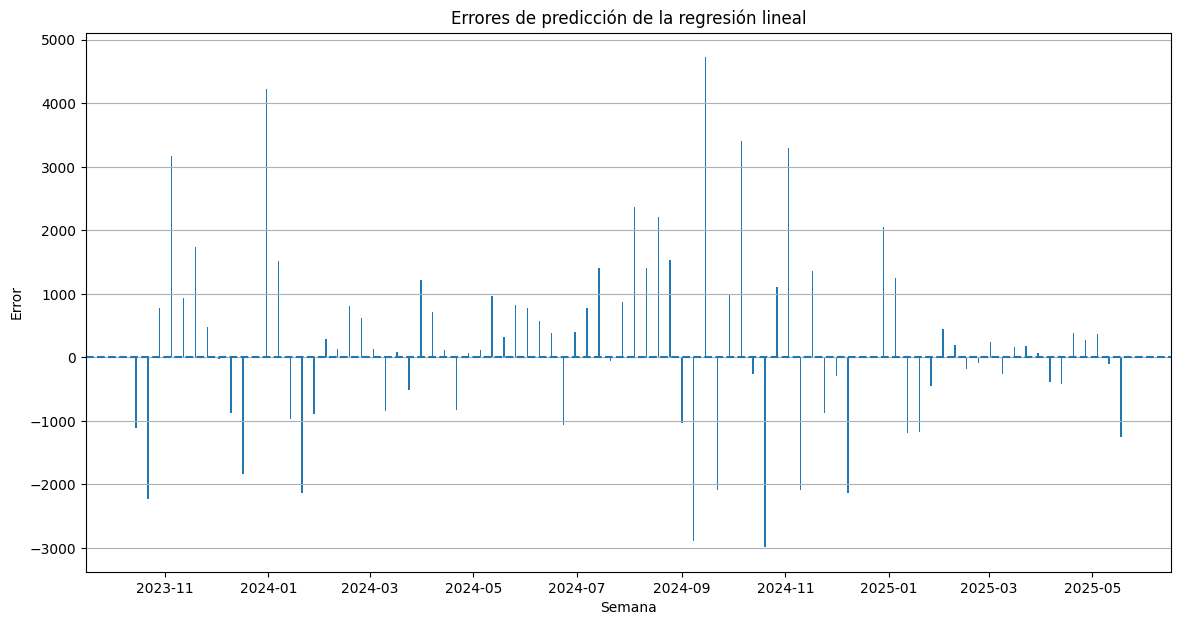

In [136]:
plt.figure(figsize=(14, 7))

plt.axhline(y=0, linestyle="--")

plt.bar(
    df_test["FECHA"],
    df_test["error_lr"]
)

plt.xlabel("Semana")
plt.ylabel("Error")
plt.title("Errores de predicción de la regresión lineal")
plt.grid(axis="y")

plt.show()

El modelo ingenuo obtuvo un MAE de 1163.36 y un RMSE de 1751.96, mientras que la regresión lineal obtuvo un MAE de 1166.222 y un RMSE de 1686.124. Como ambas métricas penalizan el error de prediccón y valores más pequeños indican mejor desempeño, el modelo ingenuo tuvo mejor rendimiento en el conjunto de prueba.

Esto significa que, para esta serie y esta partición temporal, predecir los casos de la siguiente semana como iguales a los casos de la semana actual fue más efectivo que usar una regresión lineal con rezagos y promedios móviles.


El siguiente paso natural es añadir dos modelos predictivos más: Árbol de desición y RandomForest. Carguemos las siguientes paqueterías:

In [137]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

Ya lo habíamos definido pero volvamos a poner la definición de las métricas error.

In [138]:
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    return mae, rmse

Como ya tenemos el análisis del Modelo ingenuo y de la regresión lineal, añadimos ahora el análisis del árbol de decisión y el RandomForest.

In [139]:
modelo_arbol = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

pred_arbol = np.maximum(pred_arbol, 0)

mae_arbol, rmse_arbol = calcular_metricas(y_test, pred_arbol)

print("Árbol de decisión")
print("MAE:", mae_arbol)
print("RMSE:", rmse_arbol)

Árbol de decisión
MAE: 2673.8446048275764
RMSE: 4178.9958291735375


Como una primera interpretación, el árbol de decisión es el menos preciso pues se observa un valor de $MAE$ y de $RMSE$ mayor a los otros dos modelos analizados.

Random Forest inicial

In [140]:
modelo_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=4,
    min_samples_leaf=3,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

pred_rf = np.maximum(pred_rf, 0)

mae_rf, rmse_rf = calcular_metricas(y_test, pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
MAE: 2633.620164512366
RMSE: 4081.219749313513


En este caso, considerando 50 árboles el valor de $MAE$ y de $RMSE$ mejora respecto al árbol de desición, pero sigue por encima del model ingenuo y de la regresión lineal. Veamos una tabla comparativa de todos los modelos analizados.

In [141]:
df_metricas = pd.DataFrame({
    "modelo": [
        "Naive",
        "Regresión lineal",
        "Árbol de decisión",
        "Random Forest"
    ],
    "MAE": [
        mae_naive,
        mae_lr,
        mae_arbol,
        mae_rf
    ],
    "RMSE": [
        rmse_naive,
        rmse_lr,
        rmse_arbol,
        rmse_rf
    ]
})

df_metricas.sort_values("RMSE")

,modelo,MAE,RMSE
1,Regresión lineal,1166.222515,1682.124494
0,Naive,1163.369048,1751.968243
3,Random Forest,2633.620165,4081.219749
2,Árbol de decisión,2673.844605,4178.995829


Después de esta tabla, podemos seguir en nuestro dicho, la regresión lineal hasta el momento es el mejor modelo predictor.

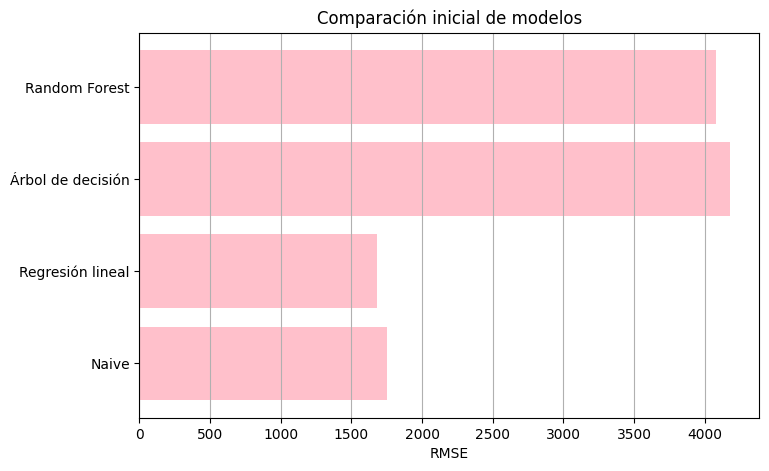

In [142]:
plt.figure(figsize=(8, 5))

plt.barh(
    df_metricas["modelo"],
    df_metricas["RMSE"], color='pink'
)

plt.xlabel("RMSE")
plt.title("Comparación inicial de modelos")
plt.grid(axis="x")

plt.show()

Ahora hagamos una gráfica de predicciones.

In [143]:
df_test["pred_lr"] = pred_lr
df_test["pred_arbol"] = pred_arbol
df_test["pred_rf"] = pred_rf

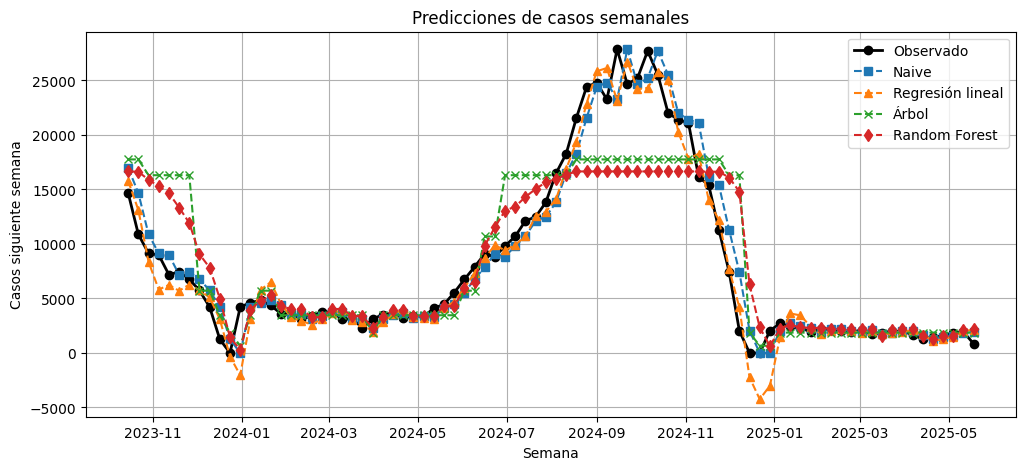

In [144]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_test["FECHA"],
    df_test["casos_siguiente_semana"],
    marker="o",
    label="Observado", color = 'black', lw=2
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_naive"],
    marker="s",
    linestyle="--",
    label="Naive"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_lr"],
    marker="^",
    linestyle="--",
    label="Regresión lineal"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_arbol"],
    marker="x",
    linestyle="--",
    label="Árbol"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_rf"],
    marker="d",
    linestyle="--",
    label="Random Forest"
)

plt.xlabel("Semana")
plt.ylabel("Casos siguiente semana")
plt.title("Predicciones de casos semanales")
plt.legend()
plt.grid()

plt.show()


Claramente se vé como el Random Forest y el árbol de decisión no predicen muy bien los contagios, el caso más notable es en los picos después de septiembre del 2024.

Hagamos un ajuste de hiperparámetros de RandomForest, para ver cual es el número de árboles adecuado. Probaremos con 10, 25, 50, 100, 200 y 300 árboles.

In [145]:
valores_arboles = [10, 25, 50, 100, 200, 300]

resultados_arboles = []

for n_est in valores_arboles:
    modelo_temp = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=4,
        min_samples_leaf=3,
        random_state=42
    )

    modelo_temp.fit(X_train, y_train)

    pred_temp = modelo_temp.predict(X_test)
    pred_temp = np.maximum(pred_temp, 0)

    mae_temp, rmse_temp = calcular_metricas(y_test, pred_temp)

    resultados_arboles.append({
        "n_estimators": n_est,
        "MAE": mae_temp,
        "RMSE": rmse_temp
    })

df_resultados_arboles = pd.DataFrame(resultados_arboles)

df_resultados_arboles


,n_estimators,MAE,RMSE
0,10,2637.432010,4044.840500
1,25,2693.413811,4157.245142
2,50,2633.620165,4081.219749
3,100,2646.823188,4126.089033
4,200,2704.727197,4204.963622
5,300,2710.484164,4195.538589


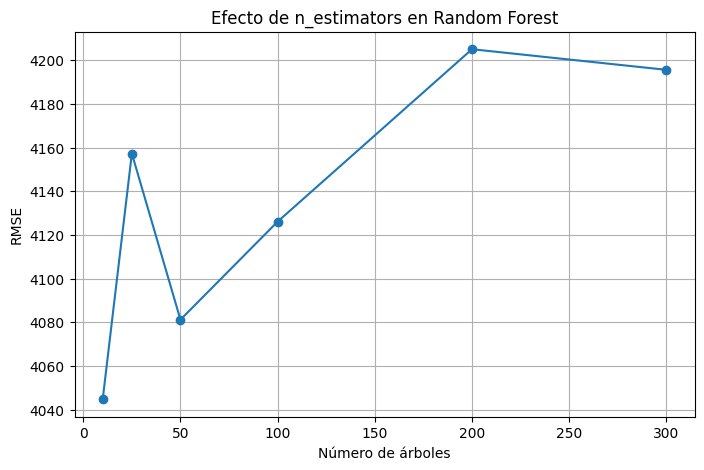

In [146]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_arboles["n_estimators"],
    df_resultados_arboles["RMSE"],
    marker="o"
)

plt.xlabel("Número de árboles")
plt.ylabel("RMSE")
plt.title("Efecto de n_estimators en Random Forest")
plt.grid()

plt.show()


Como se puede observar en el gráfico y en la tabla anterior, el menor valor de $RMSE$ se obtiene considerando 10 árboles, pues el valor del $RMSE$ siempre va a la alza después de 50 árboles.

Ahora variemos la profundidad máxima

In [147]:
valores_depth = [1, 2, 3, 4, 5, 6, 8, 10]

resultados_depth = []

for depth in valores_depth:
    modelo_temp = RandomForestRegressor(
        n_estimators=50,
        max_depth=depth,
        min_samples_leaf=3,
        random_state=42
    )

    modelo_temp.fit(X_train, y_train)

    pred_temp = modelo_temp.predict(X_test)
    pred_temp = np.maximum(pred_temp, 0)

    mae_temp, rmse_temp = calcular_metricas(y_test, pred_temp)

    resultados_depth.append({
        "max_depth": depth,
        "MAE": mae_temp,
        "RMSE": rmse_temp
    })

df_resultados_depth = pd.DataFrame(resultados_depth)

df_resultados_depth


,max_depth,MAE,RMSE
0,1,3220.864431,4526.856560
1,2,2685.974741,4076.971913
2,3,2581.474240,4025.033076
3,4,2633.620165,4081.219749
4,5,2649.173246,4106.209928
5,6,2652.772950,4108.673629
6,8,2637.343095,4098.712393
7,10,2646.030124,4098.660475


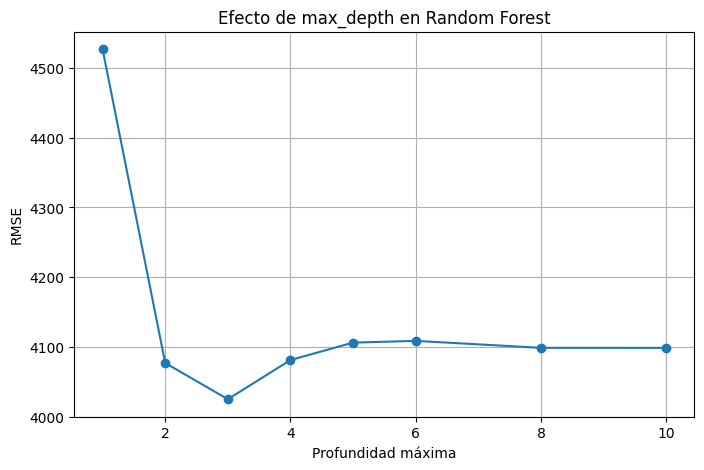

In [148]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_depth["max_depth"],
    df_resultados_depth["RMSE"],
    marker="o"
)

plt.xlabel("Profundidad máxima")
plt.ylabel("RMSE")
plt.title("Efecto de max_depth en Random Forest")
plt.grid()

plt.show()

Se aprecia que a una profundidad de 3 se alcanza el menor valor de $RMSE$ por lo que ese valor será el adecuado para mejorar el modelo.

Ahora variaremos min_samples_leaf

In [149]:
valores_leaf = [1, 2, 3, 5, 10]

resultados_leaf = []

for leaf in valores_leaf:
    modelo_temp = RandomForestRegressor(
        n_estimators=50,
        max_depth=4,
        min_samples_leaf=leaf,
        random_state=42
    )

    modelo_temp.fit(X_train, y_train)

    pred_temp = modelo_temp.predict(X_test)
    pred_temp = np.maximum(pred_temp, 0)

    mae_temp, rmse_temp = calcular_metricas(y_test, pred_temp)

    resultados_leaf.append({
        "min_samples_leaf": leaf,
        "MAE": mae_temp,
        "RMSE": rmse_temp
    })

df_resultados_leaf = pd.DataFrame(resultados_leaf)

df_resultados_leaf

,min_samples_leaf,MAE,RMSE
0,1,2606.693211,4045.913802
1,2,2500.413700,3884.640637
2,3,2633.620165,4081.219749
3,5,2942.748856,4566.694779
4,10,3285.296700,5406.804756


El modelo sigue mejorando, sin embargo, aún no se acerca a lo modelado por la regresión lineal.

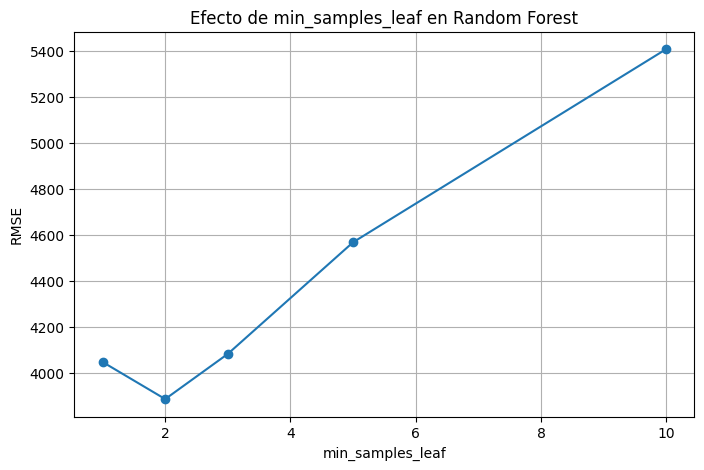

In [150]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_leaf["min_samples_leaf"],
    df_resultados_leaf["RMSE"],
    marker="o"
)

plt.xlabel("min_samples_leaf")
plt.ylabel("RMSE")
plt.title("Efecto de min_samples_leaf en Random Forest")
plt.grid()

plt.show()

Notemos que en este caso, el valor óptimo de min_samples_leaf es 2, pues ahí se minimiza el valor del $RMSE$.

Después de explorar cada hiperparámetro por separado, hacemos una búsqueda pequeña de combinaciones.

In [151]:
valores_arboles = [50, 100, 200]
valores_depth = [2, 3, 4, 5, 6]
valores_leaf = [1, 2, 3, 5]

resultados_grid = []

for n_est in valores_arboles:
    for depth in valores_depth:
        for leaf in valores_leaf:

            modelo_temp = RandomForestRegressor(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=42
            )

            modelo_temp.fit(X_train, y_train)

            pred_temp = modelo_temp.predict(X_test)
            pred_temp = np.maximum(pred_temp, 0)

            mae_temp, rmse_temp = calcular_metricas(y_test, pred_temp)

            resultados_grid.append({
                "n_estimators": n_est,
                "max_depth": depth,
                "min_samples_leaf": leaf,
                "MAE": mae_temp,
                "RMSE": rmse_temp
            })

df_grid = pd.DataFrame(resultados_grid)

df_grid.sort_values("RMSE").head(10)


,n_estimators,max_depth,min_samples_leaf,MAE,RMSE
9,50,4,2,2500.413700,3884.640637
5,50,3,2,2513.449641,3922.666530
0,50,2,1,2621.059843,3925.487207
1,50,2,2,2626.029522,3955.376142
29,100,4,2,2546.653448,3966.103536
33,100,5,2,2551.253720,3975.363126
32,100,5,1,2538.700749,3978.270331
20,100,2,1,2668.803254,3985.140373
56,200,6,1,2568.669072,3987.354973
25,100,3,2,2554.505428,3989.205897


Aquí claramente se observa lo que ya habíamos visto antes, con $n=50$, una profundidad de 4 y con 2 hojas, se obtiene el menor valor para el $MAE$ y para el $RMSE$,

$$MAE=2500.41$$
$$RMSE=3884.64$$

Entrenemos el mejor RandomForest encontrado

In [152]:
mejor_rf = df_grid.sort_values("RMSE").iloc[0]

mejor_rf

,9
n_estimators,50.000000
max_depth,4.000000
min_samples_leaf,2.000000
MAE,2500.413700
RMSE,3884.640637


In [153]:
modelo_rf_final = RandomForestRegressor(
    n_estimators=int(mejor_rf["n_estimators"]),
    max_depth=int(mejor_rf["max_depth"]),
    min_samples_leaf=int(mejor_rf["min_samples_leaf"]),
    random_state=42
)

modelo_rf_final.fit(X_train, y_train)

pred_rf_final = modelo_rf_final.predict(X_test)

pred_rf_final = np.maximum(pred_rf_final, 0)

mae_rf_final, rmse_rf_final = calcular_metricas(
    y_test,
    pred_rf_final
)

print("Random Forest final")
print("MAE:", mae_rf_final)
print("RMSE:", rmse_rf_final)

Random Forest final
MAE: 2500.413700167307
RMSE: 3884.6406368182443


Ahora hagamos una comparación final entre todos los modelos predictivos considerados.

In [154]:
df_metricas_final = pd.DataFrame({
    "modelo": [
        "Naive",
        "Regresión lineal",
        "Árbol de decisión",
        "Random Forest inicial",
        "Random Forest ajustado"
    ],
    "MAE": [
        mae_naive,
        mae_lr,
        mae_arbol,
        mae_rf,
        mae_rf_final
    ],
    "RMSE": [
        rmse_naive,
        rmse_lr,
        rmse_arbol,
        rmse_rf,
        rmse_rf_final
    ]
})

df_metricas_final.sort_values("RMSE")

,modelo,MAE,RMSE
1,Regresión lineal,1166.222515,1682.124494
0,Naive,1163.369048,1751.968243
4,Random Forest ajustado,2500.413700,3884.640637
3,Random Forest inicial,2633.620165,4081.219749
2,Árbol de decisión,2673.844605,4178.995829


La tabla muestra que el mejor desempeño se obtuvo con la regresión lineal, con un MAE de 1166.222515 y un RMSE de	1682.124494. Estos valores son menores que los obtenidos por los otros modelos: ingenuo, el árbol de decisión, el Random Forest inicial y el Random Forest ajustado.

Este resultado indica que el ajuste de hiperparámetros mejoró el desempeño del Random Forest. Sin embargo, el modelo ajustado no logró reducir el error respecto a la regresión lineal.

El árbol de decisión presentó el peor desempeño.

En conclusión, para esta partición temporal de los datos, la regresión lineal fue el modelo con mejor capacidad predictiva.

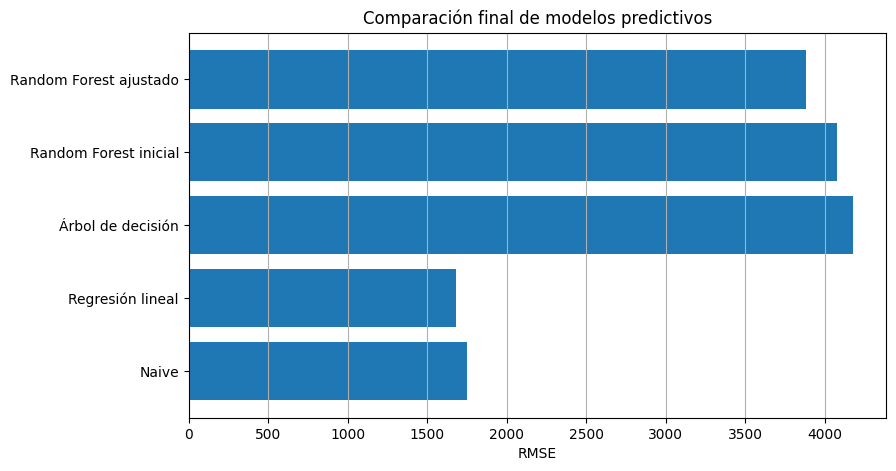

In [155]:
plt.figure(figsize=(9, 5))

plt.barh(
    df_metricas_final["modelo"],
    df_metricas_final["RMSE"]
)

plt.xlabel("RMSE")
plt.title("Comparación final de modelos predictivos")
plt.grid(axis="x")

plt.show()

In [156]:
df_test["pred_rf_final"] = pred_rf_final

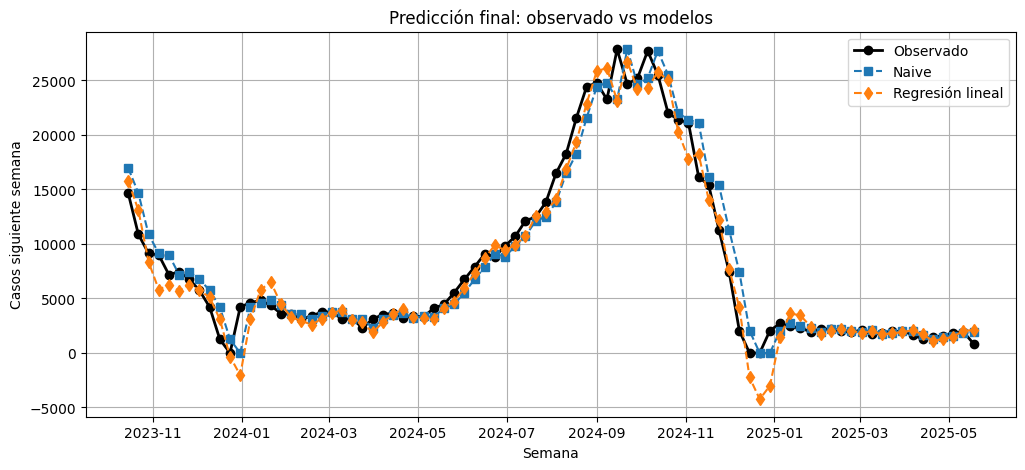

In [157]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_test["FECHA"],
    df_test["casos_siguiente_semana"],
    marker="o",
    linewidth=2,
    label="Observado", color = 'black'
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_naive"],
    marker="s",
    linestyle="--",
    label="Naive"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_lr"],
    marker="d",
    linestyle="--",
    label="Regresión lineal"
)

plt.xlabel("Semana")
plt.ylabel("Casos siguiente semana")
plt.title("Predicción final: observado vs modelos")
plt.legend()
plt.grid()

plt.show()

Ya antes vimos cual fue la importancia de cada variable predictora en la regresión lineal.

Respondamos las siguientes preguntas:

¿Qué modelo tuvo menor $MAE$? R= El NAive fué el modelo que tuvo menor $MAE$, con un valor de 1163.369.

¿Qué modelo tuvo menor $RMSE$? R= El modelo que tuvo menor $RMSE$ fue la regresión lineal, con un valor de 1682.1244.

¿El modelo más complejo fue necesariamente el mejor? R= No, en este caso el modelo más complejo que fue el RandomForest no fue el mejor, el mejor fue la regresión lineal.

¿Algún modelo logró mejorar al modelo ingenuo? R= Solamente la regresión lineal logró mejorar al modelo ingenuo, los demás fueron peores con creces.

¿Qué modelo parece capturar mejor los picos? R= La regresión lineal es el modelo que parece capturar mejor los picos.

¿En qué periodos se observan los mayores errores? R= Basando nuestra respuesta en el modelo óptimo, los mayores errores se observan al inicio del 2024 y al inicio del 2025, en la primer semana de ambos años.

***Parte 4: Clasificación de semanas de riesgo.***

Transformemos el problema en un problema de clasificación supervisada. Lo que haremos es, en lugar de predecir casos exactos, lo que haremos es clasificar la siguiente semana como: riesgo bajo, riesgo medio, riesgo alto.

Carguemos nuestras nuevas librerías

In [158]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Aparte de las variables temporales que creamos al inicio ($C_{t-1}, C_{t-2}, C_{t-3}, C_{t-4}, MA_{3}, MA_{5}, \Delta C_{t}$), crearemos una razón de cambio relativa, dada por

$$\frac{C_{t}-C_{t-1}}{C_{t-1}}$$

In [159]:
df["lag_1"] = df["casos_semana"].shift(1)
df["lag_2"] = df["casos_semana"].shift(2)
df["lag_3"] = df["casos_semana"].shift(3)
df["lag_4"] = df["casos_semana"].shift(4)

df["promedio_movil_3"] = df["casos_semana"].rolling(window=3).mean()
df["promedio_movil_5"] = df["casos_semana"].rolling(window=5).mean()

df["cambio_semanal"] = df["casos_semana"].diff()

df["cambio_relativo"] = (
    df["casos_semana"] - df["lag_1"]
) / df["lag_1"]

df["cambio_relativo"] = df["cambio_relativo"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [160]:
df["casos_siguiente_semana"] = df["casos_semana"].shift(-1)

df.head(10)

,FECHA,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,COAHUILA,COLIMA,DISTRITO FEDERAL,...,casos_semana,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,cambio_semanal,casos_siguiente_semana,cambio_relativo
0,2020-01-05,0,2,4,36,41,1,4,23,6,...,1318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2068.0,NaN
1,2020-01-12,0,2,3,37,83,5,1,37,6,...,2068,1318.0,NaN,NaN,NaN,NaN,NaN,750.0,2078.0,0.569044
2,2020-01-19,0,0,3,31,73,0,4,40,2,...,2078,2068.0,1318.0,NaN,NaN,1821.333333,NaN,10.0,1973.0,0.004836
3,2020-01-26,1,1,2,45,57,0,1,39,3,...,1973,2078.0,2068.0,1318.0,NaN,2039.666667,NaN,-105.0,1562.0,-0.050529
4,2020-02-02,0,0,2,40,54,0,1,32,0,...,1562,1973.0,2078.0,2068.0,1318.0,1871.000000,1799.8,-411.0,1659.0,-0.208312
5,2020-02-09,0,0,4,64,78,0,2,34,1,...,1659,1562.0,1973.0,2078.0,2068.0,1731.333333,1868.0,97.0,1593.0,0.062100
6,2020-02-16,1,0,2,33,58,0,7,47,1,...,1593,1659.0,1562.0,1973.0,2078.0,1604.666667,1773.0,-66.0,1756.0,-0.039783
7,2020-02-23,1,0,6,37,58,0,4,56,1,...,1756,1593.0,1659.0,1562.0,1973.0,1669.333333,1708.6,163.0,1598.0,0.102323
8,2020-03-01,0,0,1,36,46,0,3,57,2,...,1598,1756.0,1593.0,1659.0,1562.0,1649.000000,1633.6,-158.0,1384.0,-0.089977
9,2020-03-08,0,0,1,30,72,0,1,54,0,...,1384,1598.0,1756.0,1593.0,1659.0,1579.333333,1598.0,-214.0,1200.0,-0.133917


Usando cuantiles, crearemos las categorías de riesgo.

In [161]:
df["riesgo_siguiente_semana"], cortes = pd.qcut(
    df["casos_siguiente_semana"],
    q=3,
    labels=["riesgo bajo", "riesgo medio", "riesgo alto"],
    retbins=True
)

In [162]:
df_cortes = pd.DataFrame({
    "categoria": ["riesgo bajo", "riesgo medio", "riesgo alto"],
    "desde": [cortes[0], cortes[1], cortes[2]],
    "hasta": [cortes[1], cortes[2], cortes[3]]
})

df_cortes

,categoria,desde,hasta
0,riesgo bajo,0.000000,994.000000
1,riesgo medio,994.000000,2708.333333
2,riesgo alto,2708.333333,27869.000000


Entonces, la clasificación queda como:

In [163]:
df[["FECHA", "casos_semana", "casos_siguiente_semana", "riesgo_siguiente_semana"]]

,FECHA,casos_semana,casos_siguiente_semana,riesgo_siguiente_semana
0,2020-01-05,1318,2068.0,riesgo medio
1,2020-01-12,2068,2078.0,riesgo medio
2,2020-01-19,2078,1973.0,riesgo medio
3,2020-01-26,1973,1562.0,riesgo medio
4,2020-02-02,1562,1659.0,riesgo medio
...,...,...,...,...
277,2025-04-27,1504,1549.0,riesgo medio
278,2025-05-04,1549,1878.0,riesgo medio
279,2025-05-11,1878,1932.0,riesgo medio
280,2025-05-18,1932,849.0,riesgo bajo


In [164]:
df["riesgo_siguiente_semana"].value_counts()

,count
riesgo_siguiente_semana,
riesgo bajo,94
riesgo alto,94
riesgo medio,93


Como observamos, la clasisficación de las semanas, por riesgo, está balanceada, como se quería.

Hay 94 semanas de riesgo bajo, 94 semanas de riesgo alto y 93 semanas de riesgo alto.

La tabla que consideraremos para hacer nuestros análisis será la siguiente, ya usada arriba.

In [165]:
columnas_modelo = [
    "FECHA",
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal",
    "cambio_relativo",
    "casos_siguiente_semana",
    "riesgo_siguiente_semana"
]

df_modelo = df[columnas_modelo].dropna().reset_index(drop=True)

df_modelo.head()

,FECHA,casos_semana,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,cambio_semanal,cambio_relativo,casos_siguiente_semana,riesgo_siguiente_semana
0,2020-02-02,1562,1973.0,2078.0,2068.0,1318.0,1871.000000,1799.8,-411.0,-0.208312,1659.0,riesgo medio
1,2020-02-09,1659,1562.0,1973.0,2078.0,2068.0,1731.333333,1868.0,97.0,0.062100,1593.0,riesgo medio
2,2020-02-16,1593,1659.0,1562.0,1973.0,2078.0,1604.666667,1773.0,-66.0,-0.039783,1756.0,riesgo medio
3,2020-02-23,1756,1593.0,1659.0,1562.0,1973.0,1669.333333,1708.6,163.0,0.102323,1598.0,riesgo medio
4,2020-03-01,1598,1756.0,1593.0,1659.0,1562.0,1649.000000,1633.6,-158.0,-0.089977,1384.0,riesgo medio


In [166]:
variables_predictoras = [
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal",
    "cambio_relativo"
]

X = df_modelo[variables_predictoras]

y = df_modelo["riesgo_siguiente_semana"]

print(X.head())
print(y.head())

   casos_semana   lag_1   lag_2   lag_3   lag_4  promedio_movil_3  \
0          1562  1973.0  2078.0  2068.0  1318.0       1871.000000   
1          1659  1562.0  1973.0  2078.0  2068.0       1731.333333   
2          1593  1659.0  1562.0  1973.0  2078.0       1604.666667   
3          1756  1593.0  1659.0  1562.0  1973.0       1669.333333   
4          1598  1756.0  1593.0  1659.0  1562.0       1649.000000   

   promedio_movil_5  cambio_semanal  cambio_relativo  
0            1799.8          -411.0        -0.208312  
1            1868.0            97.0         0.062100  
2            1773.0           -66.0        -0.039783  
3            1708.6           163.0         0.102323  
4            1633.6          -158.0        -0.089977  
0    riesgo medio
1    riesgo medio
2    riesgo medio
3    riesgo medio
4    riesgo medio
Name: riesgo_siguiente_semana, dtype: category
Categories (3, object): ['riesgo bajo' < 'riesgo medio' < 'riesgo alto']


Estas serán nuestras variables predictoras y nuestra varible objetivo, la interpretación será:
$$X= \text{Información disponible hasta la semana } t$$

$$y= \text{categoría de riesgo de la semana } t+1$$

Modelo ingenuo para la clasificación.

Primero debemos clasificar el riesgo actual.

In [167]:
df_modelo["riesgo_actual"] = pd.qcut(
    df_modelo["casos_semana"],
    q=3,
    labels=["riesgo bajo", "riesgo medio", "riesgo alto"]
)

Como modificamos df_modelo, debemos reconstruir df_train y df_test.

In [168]:
n = len(df_modelo)
n_train = int(0.7 * n)

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["riesgo_siguiente_semana"]

X_test = df_test[variables_predictoras]
y_test = df_test["riesgo_siguiente_semana"]

df_test["pred_naive"] = df_test["riesgo_actual"]

Ahora, veamos cuál es el valor del accuracy para el modelo ingenuo.

In [169]:
acc_naive = accuracy_score(y_test, df_test["pred_naive"])

print("Accuracy modelo ingenuo:", acc_naive)

Accuracy modelo ingenuo: 0.9012345679012346


Recordemos que el modelo ingenuo establece que en nivel de riesgo en los contagios de esta semaná será el mismo que el riesgo de la siguiente semana.

Veamos el árbol de desición para la clasificación.

In [170]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, pred_arbol)

print("Accuracy árbol de decisión:", acc_arbol)

Accuracy árbol de decisión: 0.9012345679012346


Random forest para la clasificación.

In [171]:
modelo_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_leaf=2,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.9012345679012346


En la siguiente tabla se encuentra la comparación inicial de los modelos.

In [172]:
df_metricas = pd.DataFrame({
    "modelo": [
        "Naive",
        "Árbol de decisión",
        "Random Forest"
    ],
    "accuracy": [
        acc_naive,
        acc_arbol,
        acc_rf
    ]
})

df_metricas

,modelo,accuracy
0,Naive,0.901235
1,Árbol de decisión,0.901235
2,Random Forest,0.901235


Para el RandomForest, hagamos:

matriz de confusión;

reporte de clasificación;

interpretación de precision;

interpretación de recall;

interpretación de F1-score.

Matriz de confusión:

In [173]:
print(type(y_test))
print(y_test.dtype)

print(pd.unique(y_test))
print(pd.unique(pred_rf))

<class 'pandas.core.series.Series'>
category
['riesgo alto', 'riesgo medio', 'riesgo bajo']
Categories (3, object): ['riesgo bajo' < 'riesgo medio' < 'riesgo alto']
['riesgo alto' 'riesgo bajo' 'riesgo medio']


In [174]:
labels = ["riesgo bajo", "riesgo medio", "riesgo alto"]

def matriz_confusion_df(y_real, y_pred, labels):
    cm = confusion_matrix(y_real, y_pred, labels=labels)

    df_cm = pd.DataFrame(
        cm,
        index=[f"Real {l}" for l in labels],
        columns=[f"Pred {l}" for l in labels]
    )

    return df_cm

In [175]:
print("Matriz de confusión Random-Forest")

y_test_str = y_test.astype(str)
pred_rf_str = pd.Series(pred_rf).astype(str)

display(matriz_confusion_df(y_test_str, pred_rf_str, labels))

Matriz de confusión Random-Forest


,Pred riesgo bajo,Pred riesgo medio,Pred riesgo alto
Real riesgo bajo,1,1,2
Real riesgo medio,0,18,3
Real riesgo alto,1,1,54


Recordemos que las filas son las clases reales, las columnas son las clases predichas, los valores de la diagonal principal son aciertos y los valores fuera de la diagonal son errores de clasificación.

Entonces, Random-Forest predijo 1 semana de riesgo bajo, 0 de riesgo medio y 1 de riesgo alto.

Significa que hubo 1 semana de riesgo bajo y el modelo la clasificó correctamente. Hubo 18 de riesgo medio, y las clasificó correctamente. También hubo 54 semanas de riesgo alto y el modelo las predijo correctamente.

El número total de aciertos es: 1+18+54=73.

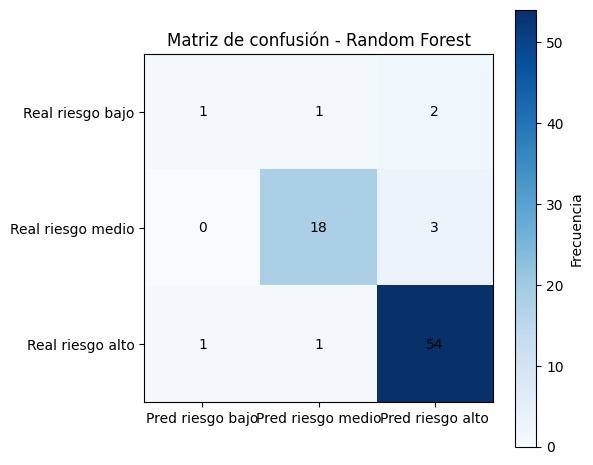

In [176]:
df_cm_rf = matriz_confusion_df(y_test, pred_rf, labels)

plt.figure(figsize=(6, 5))

plt.imshow(df_cm_rf, cmap='Blues')

plt.xticks(range(len(labels)), [f"Pred {l}" for l in labels])
plt.yticks(range(len(labels)), [f"Real {l}" for l in labels])

plt.title("Matriz de confusión - Random Forest")
plt.colorbar(label="Frecuencia")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            df_cm_rf.iloc[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

¿Qué clase se predice mejor? R= La clase que se predice mejor es la clase de riesgo alto.

¿Qué clase se confunde más? R= La clase que se confunde más, es decir, la que se predice con menor precisión es la de riesgo bajo.

¿El modelo detecta bien las semanas de riesgo alto? R= Si, las predice con bastante exactitud.

¿Confunde semanas de riesgo medio con riesgo bajo o alto? R=No, realmente predice mucho mejor las de riesgo medio que las de riesgo bajo.

¿Qué implicaría esto en un contexto epidemiológico? R=Que el modeló será precis cuando haya muchos contagios, pero una vez que la gente se vacune, o se cuide más, como consecuencia los contagios bajarían y el modelo haaría predicciones menos precisas.

Hagamos el reporte de clasificación:

In [177]:
print("Reporte - Random Forest")
print(classification_report(y_test, pred_rf))

Reporte - Random Forest
              precision    recall  f1-score   support

 riesgo alto       0.92      0.96      0.94        56
 riesgo bajo       0.50      0.25      0.33         4
riesgo medio       0.90      0.86      0.88        21

    accuracy                           0.90        81
   macro avg       0.77      0.69      0.72        81
weighted avg       0.89      0.90      0.89        81



Interpretación para el Random Forest

Support indica cuántas semanas reales hay de cada clase en el conjunto de prueba:


1.   Riesgo alto-56 semnas reales
2.   Riesgo medio-21 semanas reales
3.   Riesgo bajo-4 semanas reales

entonces en nuestro conjunto de prueba había 81 semanas.

La precision responde de todas las semnas que el modelo predijo como cierta clase, ¿cuántas realmente eran de esa clase?



1.   Para la clase alto: valor 0.92. Esto significa que de todas las semanas que el modelo clasificó como riesgo alto, el 92% realmente eran de riesgo alto.
2.   Para la clase bajo: valor 0.50. Esto significa que de las semanas que el modelo clasificó como de riesgo bajo, el 50% realmente sera de riesgo bajo.
3. Para la clase medio: valor 0.90. Esto implica que de las semanas que el modelo clasificó como de riesgo medio, el 90% realmente era de riesgo medio.

El recall nos dice que de todas las semanas que realmente eran de cierta claase, cuántas detectó correctamente el modelo.



1.   recall alto: 0.96 esto significa que de todas las semanas realmente altas, el modelo detectó correctamente el 96%.
2.   recall bajo: 0.25 esto significa que de todas las semanas realmente de riesgo bajo, el modelo predijo correctamente el 25%.
3. recall medio: 0.86 significa que de todas las semanas de riesgo medio, el problemá detectó correctamente el 86%.

La clase problemática es la de riesgo bajo, pues la predice con menor presición.

El f1-score combina precisión y recall en una sola medida. Sirve para resumir el desempeño de cada clase.



1.   Clase alto: 0.94 podríamos decir que tiene un muy buen desempeño.
2.   Clase bajo: 0.33 se interpreta que tiene un desempeño bajo.
3.   Clase media: 0.88 tiene un desempeño muy bueno.









Parte 7. Veamos la importancia de variables en el RandomForest.

In [178]:
importancias = pd.DataFrame({
    "variable": variables_predictoras,
    "importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    "importancia",
    ascending=False
)

importancias

,variable,importancia
0,casos_semana,0.341058
1,lag_1,0.203766
5,promedio_movil_3,0.172515
6,promedio_movil_5,0.081178
2,lag_2,0.069040
7,cambio_semanal,0.056348
3,lag_3,0.033208
8,cambio_relativo,0.029694
4,lag_4,0.013193


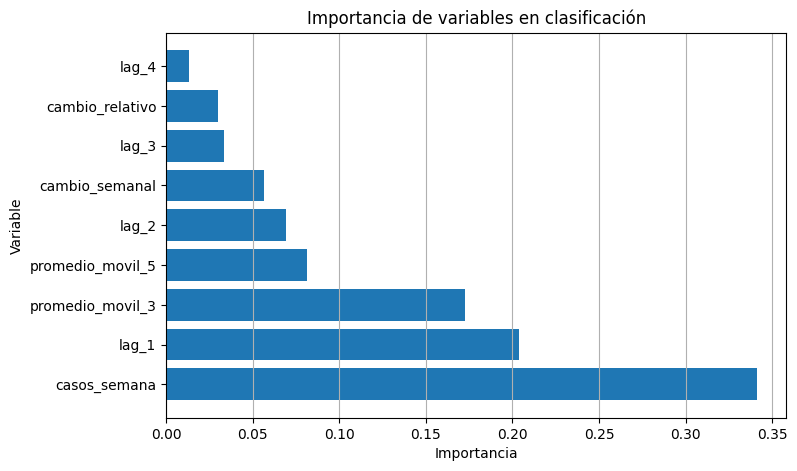

In [179]:
plt.figure(figsize=(8, 5))

plt.barh(
    importancias["variable"],
    importancias["importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables en clasificación")
plt.grid(axis="x")

plt.show()

Respondamos las siguientes preguntas:

¿Cuál fue la variable más importante? Sol: La variable más importante fué la variable casos_semana con creces. Algunas otras importantes fueron la variable lag_1 y el promedio_movil_3.

¿Los casos actuales $(C_t)$ fueron más importantes que los rezagos? Sol: Si, de echo fue la variable más importante en todo el modelo.

¿Los promedios móviles aportaron información? Sol: Solo el promedio móvil de 3 semanas, el de 5 semanas tuvo una relevancia media-baja, no influyó tanto en el modelo.

¿El cambio semanal fue relevante? Sol: Podríamos considerar que no tuvo relevancia pues tuvo un valor bastante pequeño.

¿La importancia de variables debe interpretarse como causalidad? Sol: Pues si, pues por ejemplo, si esta semana se consideró de alto riesgo porque hubo muchos contagios, podríamos pensar que estuvo altamente influenciada por la semana anterior, que seguramente también fué de alto riesgo.

Ahora, a manera de complementar nuestro análisis, convirtamos las clases a números para graficar.

In [187]:
mapa_riesgo = {
    "riesgo bajo": 0,
    "riesgo medio": 1,
    "riesgo alto": 2
}

df_test["riesgo_real_num"] = df_test["riesgo_siguiente_semana"].map(mapa_riesgo)
df_test["riesgo_rf_num"] = pd.Series(pred_rf, index=df_test.index).map(mapa_riesgo)
df_test["riesgo_naive_num"] = df_test["pred_naive"].map(mapa_riesgo)

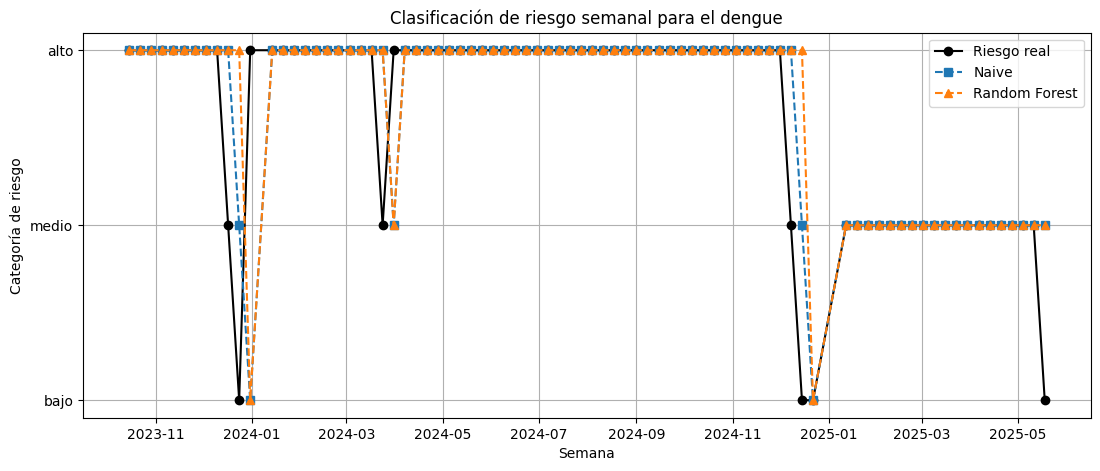

In [188]:
plt.figure(figsize=(13, 5))

plt.plot(
    df_test["FECHA"],
    df_test["riesgo_real_num"],
    marker="o",
    label="Riesgo real",
    color='black'
)

plt.plot(
    df_test["FECHA"],
    df_test["riesgo_naive_num"],
    marker="s",
    linestyle="--",
    label="Naive"
)

plt.plot(
    df_test["FECHA"],
    df_test["riesgo_rf_num"],
    marker="^",
    linestyle="--",
    label="Random Forest"
)

plt.yticks([0, 1, 2], ["bajo", "medio", "alto"])

plt.xlabel("Semana")
plt.ylabel("Categoría de riesgo")
plt.title("Clasificación de riesgo semanal para el dengue")
plt.legend()
plt.grid()

plt.show()


Ahora, a modo de mejorar el modelo, hagamos un ajuste de hiperparámetros para el RandomForest

In [189]:
valores_arboles = [50, 100, 200]
valores_depth = [2, 3, 4, 5, 6]
valores_leaf = [1, 3, 5, 10]

resultados = []

for n_est in valores_arboles:
    for depth in valores_depth:
        for leaf in valores_leaf:

            modelo_temp = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=42
            )

            modelo_temp.fit(X_train, y_train)

            pred_temp = modelo_temp.predict(X_test)

            acc_temp = accuracy_score(y_test, pred_temp)

            resultados.append({
                "n_estimators": n_est,
                "max_depth": depth,
                "min_samples_leaf": leaf,
                "accuracy": acc_temp
            })

df_grid = pd.DataFrame(resultados)

df_grid.sort_values("accuracy", ascending=False).head(10)


,n_estimators,max_depth,min_samples_leaf,accuracy
0,50,2,1,0.91358
1,50,2,3,0.91358
2,50,2,5,0.91358
3,50,2,10,0.91358
7,50,3,10,0.91358
11,50,4,10,0.91358
22,100,2,5,0.91358
23,100,2,10,0.91358
27,100,3,10,0.91358
21,100,2,3,0.91358


In [190]:
mejor = df_grid.sort_values("accuracy", ascending=False).iloc[0]

mejor

,0
n_estimators,50.00000
max_depth,2.00000
min_samples_leaf,1.00000
accuracy,0.91358


El mejor ajuste para el random forest es con $n=50$ árboles, una profundidad de 2 y un mínimo de 1 hoja.

In [191]:
modelo_rf_final = RandomForestClassifier(
    n_estimators=int(mejor["n_estimators"]),
    max_depth=int(mejor["max_depth"]),
    min_samples_leaf=int(mejor["min_samples_leaf"]),
    random_state=42
)

modelo_rf_final.fit(X_train, y_train)

pred_rf_final = modelo_rf_final.predict(X_test)

acc_rf_final = accuracy_score(y_test, pred_rf_final)

print("Random Forest ajustado")
print("Accuracy:", acc_rf_final)

Random Forest ajustado
Accuracy: 0.9135802469135802


El modelo si mejora si valor de accuracy, aunque es poca la mejora, ahora es más preciso.

In [192]:
df_metricas_final = pd.DataFrame({
    "modelo": [
        "Naive",
        "Árbol",
        "Random Forest inicial",
        "Random Forest ajustado"
    ],
    "accuracy": [
        acc_naive,
        acc_arbol,
        acc_rf,
        acc_rf_final
    ]
})

df_metricas_final.sort_values("accuracy", ascending=False)

,modelo,accuracy
3,Random Forest ajustado,0.913580
0,Naive,0.901235
1,Árbol,0.901235
2,Random Forest inicial,0.901235


In [193]:
df_cm_final = matriz_confusion_df(
    y_test,
    pred_rf_final,
    labels
)

df_cm_final

,Pred riesgo bajo,Pred riesgo medio,Pred riesgo alto
Real riesgo bajo,1,1,2
Real riesgo medio,0,18,3
Real riesgo alto,0,1,55


In [194]:
print(classification_report(y_test, pred_rf_final))

              precision    recall  f1-score   support

 riesgo alto       0.92      0.98      0.95        56
 riesgo bajo       1.00      0.25      0.40         4
riesgo medio       0.90      0.86      0.88        21

    accuracy                           0.91        81
   macro avg       0.94      0.70      0.74        81
weighted avg       0.92      0.91      0.90        81



Comparación final de modelos.

La tabla muestra en general los modelos se desempeñaron de la misma manera, pero el random forest ajustado tuvo el mejor accuracy, con un valor de 0.9135. Esto significa que clasificó correctamente aproximadamente el 91.35% de las semanas del conjunto de prueba.

El Random Forest inicial obtuvo un accuracy de 0.9012.


Parte 8. Conclusiones finales.

¿Qué se observó en la serie nacional de dengue?

R= La serie presenta una alta variabilidad temporal, con periodos de baja incidencia y un brote muy marcado durante 2024. Se analizaron 282 semanas con un total acumulado de 1,077,917 casos. El promedio semanal fue de 3,822 casos, mientras que el máximo semanal alcanzó 27,869 casos en la semana del 22 de septiembre de 2024. Además, se observa que los picos epidémicos son difíciles de predecir para algunos modelos.

¿Qué modelo funcionó mejor para predecir casos?

R= La regresión lineal fue el modelo con mejor desempeño global para la predicción de casos, ya que obtuvo el menor RMSE (1682.12), superando al modelo ingenuo, al árbol de decisión y a los modelos Random Forest.

¿Qué modelo funcionó mejor para clasificar riesgo?

R= En la clasificación, los tres modelos (Naive, Árbol de decisión y Random Forest) obtuvieron exactamente la misma exactitud, aproximadamente 0.90, por lo que ninguno mostró una ventaja clara sobre los demás.

¿El modelo más complejo fue siempre el mejor?

R= No. Los modelos más complejos (Árbol de decisión y Random Forest) no superaron a los modelos más simples. De hecho, la regresión lineal tuvo mejor desempeño predictivo que los modelos basados en árboles, y en clasificación el Random Forest no mejoró la exactitud respecto al modelo ingenuo.

¿Qué tan útil fue el modelo ingenuo?

R= Fue sorprendentemente útil. Obtuvo el menor MAE (1163.37) y una exactitud de clasificación cercana al 90%. Esto sugiere que existe una fuerte dependencia temporal entre semanas consecutivas: la situación epidemiológica de una semana suele parecerse mucho a la de la siguiente.

¿Qué variables fueron más importantes?

R= De acuerdo con el análisis de la regresión lineal realizado, las variables más importantes fueron las relacionadas con el comportamiento reciente de la serie, especialmente los casos observados en semanas anteriores (rezagos temporales). Estas variables contienen la mayor parte de la información predictiva para estimar los casos de la semana siguiente.

¿Qué limitaciones tiene el análisis?

R= Solo se utilizó la información histórica de casos de dengue. El periodo analizado es relativamente corto para capturar todos los patrones epidemiológicos posibles.
Los modelos tienen dificultades para anticipar los picos epidémicos más extremos. No se incorporaron factores externos que influyen en la transmisión del dengue. La evaluación se realizó sobre una única partición temporal de los datos.

¿Qué información adicional podría mejorar los modelos?

R= Variables meteorológicas (temperatura, precipitación, humedad). Información entomológica sobre la población del mosquito vector. Datos demográficos y de movilidad de la población. Información geográfica por estado o municipio. Indicadores de campañas de prevención y control epidemiológico. Datos de años adicionales para aumentar el tamaño de la serie temporal.

Estas variables podrían ayudar especialmente a mejorar la predicción de brotes y cambios bruscos en la incidencia del dengue.